# Modelling — Day-Ahead French Power Price Forecasting
**EDHEC MSc Data Analysis & AI — Master's Thesis**

Models trained:
- **Naive** — same hour previous day (benchmark)
- **ARIMA** — time-series statistical baseline
- **Random Forest** — main model
- **XGBoost** — gradient-boosted alternative

Evaluation: walk-forward expanding window on last 12 months (2024)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.config import PROCESSED_DIR, FIGURES_DIR, METRICS_DIR, TEST_MONTHS, RF_PARAMS, XGB_PARAMS
from src.features import build_feature_matrix
from src.models import train_random_forest, train_xgboost, naive_forecast
from src.evaluate import compute_all, save_metrics
from src.backtest import walk_forward_backtest, summarise_backtest

sns.set_theme(style='whitegrid', palette='muted')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print('Loading feature matrix...')
df = pd.read_parquet(PROCESSED_DIR / 'features.parquet')
print(f'{len(df):,} rows x {df.shape[1]} columns')
df.head(3)

Loading feature matrix...
61,176 rows x 29 columns


,load_forecast_mw,gen_gas_mw,gen_hydro_ror_mw,gen_hydro_reservoir_mw,gen_nuclear_mw,gen_solar_mw,gen_wind_onshore_mw,temperature_2m,solar_radiation,precipitation,...,price_da_eur_mwh_lag24h,price_da_eur_mwh_lag48h,price_da_eur_mwh_lag168h,price_da_eur_mwh_roll24h_mean,price_da_eur_mwh_roll168h_mean,hdd,cdd,wind_power_proxy,weather_stress_index,price_da_eur_mwh
2018-01-08 00:00:00+01:00,59650.0,2679.0,5738.0,2373.0,52474.0,0.0,5320.0,6.492950,0.0,0.000146,...,21.87,29.45,6.74,35.892917,NaN,9.007050,0.0,100.164597,1.939447,18.91
2018-01-08 01:00:00+01:00,57050.0,2735.0,5664.0,1675.0,52080.0,0.0,5292.0,6.373566,0.0,0.000145,...,15.98,28.55,4.74,35.369167,NaN,9.126434,0.0,98.367882,1.977046,15.15
2018-01-08 02:00:00+01:00,56200.0,2738.0,5624.0,1706.0,51896.0,0.0,5104.0,6.263000,0.0,0.000144,...,15.99,28.18,3.66,34.861250,NaN,9.237000,0.0,93.005081,2.038741,15.11


## 1. Train / Test Split

In [2]:
TARGET = 'price_da_eur_mwh'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Last 12 months as test set
cutoff = len(X) - TEST_MONTHS * 30 * 24
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]

print(f'Train: {len(X_train):,} hours ({X_train.index.min().date()} -> {X_train.index.max().date()})')
print(f'Test:  {len(X_test):,} hours ({X_test.index.min().date()} -> {X_test.index.max().date()})')
print(f'Features: {X_train.shape[1]}')

Train: 52,536 hours (2018-01-08 -> 2024-01-05)
Test:  8,640 hours (2024-01-06 -> 2024-12-30)
Features: 28


## 2. Naive Benchmark

In [3]:
y_pred_naive = naive_forecast(y).loc[y_test.index]
valid = y_test.notna() & y_pred_naive.notna()
metrics_naive = compute_all(y_test[valid], y_pred_naive[valid])
save_metrics(metrics_naive, 'naive')
print('Naive benchmark:')
for k, v in metrics_naive.items():
    print(f'  {k.upper()}: {v:.3f}')

Naive benchmark:
  MAE: 20.369
  RMSE: 28.370
  MAPE: 1832.108
  R2: 0.514


## 3. Random Forest

In [4]:
print('Training Random Forest...')
rf = train_random_forest(X_train, y_train)
y_pred_rf = pd.Series(rf.predict(X_test), index=y_test.index, name='rf')

metrics_rf = compute_all(y_test, y_pred_rf)
save_metrics(metrics_rf, 'random_forest')
print('Random Forest:')
for k, v in metrics_rf.items():
    print(f'  {k.upper()}: {v:.3f}')

Training Random Forest...
Random Forest:
  MAE: 15.714
  RMSE: 20.802
  MAPE: 2611.613
  R2: 0.739


## 4. XGBoost

In [5]:
print('Training XGBoost...')
xgb = train_xgboost(X_train, y_train)
y_pred_xgb = pd.Series(xgb.predict(X_test), index=y_test.index, name='xgb')

metrics_xgb = compute_all(y_test, y_pred_xgb)
save_metrics(metrics_xgb, 'xgboost')
print('XGBoost:')
for k, v in metrics_xgb.items():
    print(f'  {k.upper()}: {v:.3f}')

Training XGBoost...
XGBoost:
  MAE: 15.356
  RMSE: 20.106
  MAPE: 2323.846
  R2: 0.756


## 5. Results Comparison

In [6]:
results = pd.DataFrame({
    'Naive':         metrics_naive,
    'Random Forest': metrics_rf,
    'XGBoost':       metrics_xgb,
}).T.round(3)

results.columns = ['MAE (€/MWh)', 'RMSE (€/MWh)', 'MAPE (%)', 'R²']
print(results.to_string())
results.to_csv(FIGURES_DIR.parent / 'tables' / 'model_comparison.csv')
results

               MAE (€/MWh)  RMSE (€/MWh)  MAPE (%)     R²
Naive               20.369        28.370  1832.108  0.514
Random Forest       15.714        20.802  2611.613  0.739
XGBoost             15.356        20.106  2323.846  0.756


,MAE (€/MWh),RMSE (€/MWh),MAPE (%),R²
Naive,20.369,28.370,1832.108,0.514
Random Forest,15.714,20.802,2611.613,0.739
XGBoost,15.356,20.106,2323.846,0.756


## 6. Forecast vs Actual — Visual Comparison

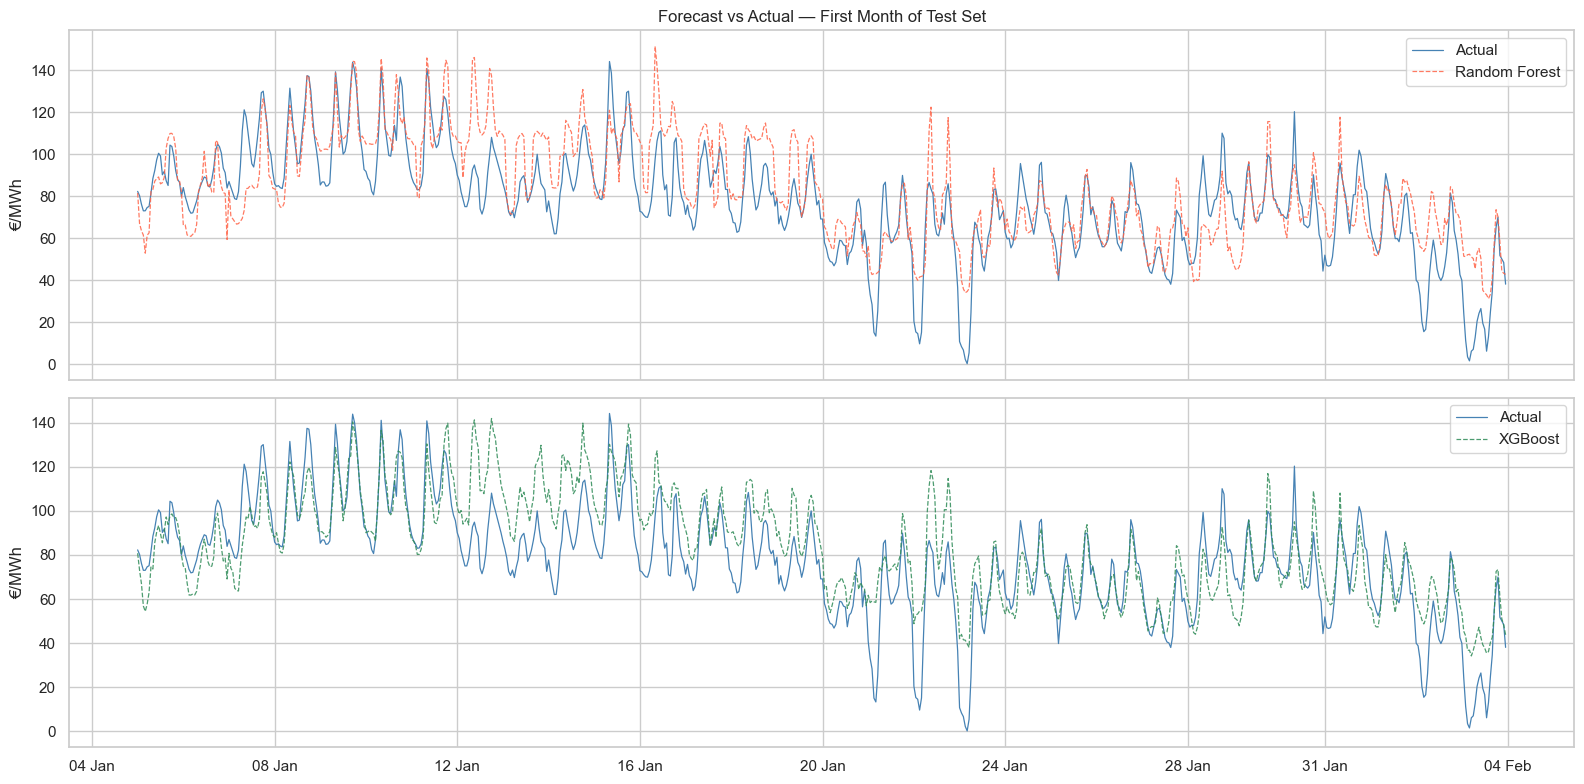

In [7]:
# Plot one month of test set for readability
sample = y_test.iloc[:24*30]
rf_sample  = y_pred_rf.iloc[:24*30]
xgb_sample = y_pred_xgb.iloc[:24*30]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, pred, name, color in [
    (axes[0], rf_sample,  'Random Forest', 'tomato'),
    (axes[1], xgb_sample, 'XGBoost',       'seagreen'),
]:
    ax.plot(sample.index, sample.values, label='Actual', color='steelblue', linewidth=0.9)
    ax.plot(pred.index, pred.values, label=name, color=color, linewidth=0.9, linestyle='--', alpha=0.85)
    ax.set_ylabel('€/MWh')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

axes[0].set_title('Forecast vs Actual — First Month of Test Set')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'forecast_vs_actual.png', dpi=150)
plt.show()

## 7. Error Distribution

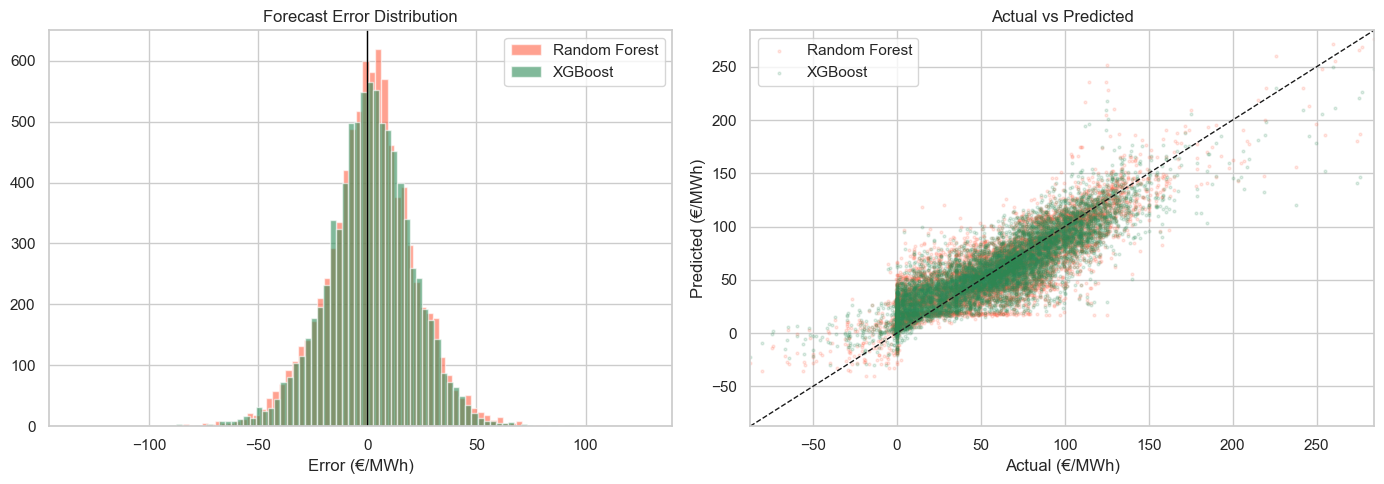

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

errors_rf  = y_pred_rf  - y_test
errors_xgb = y_pred_xgb - y_test

axes[0].hist(errors_rf,  bins=80, alpha=0.6, label='Random Forest', color='tomato',   edgecolor='white')
axes[0].hist(errors_xgb, bins=80, alpha=0.6, label='XGBoost',       color='seagreen', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Forecast Error Distribution')
axes[0].set_xlabel('Error (€/MWh)')
axes[0].legend()

# Scatter actual vs predicted
lims = [y_test.min(), min(y_test.max(), 400)]
axes[1].scatter(y_test, y_pred_rf,  alpha=0.15, s=4, color='tomato',   label='Random Forest')
axes[1].scatter(y_test, y_pred_xgb, alpha=0.15, s=4, color='seagreen', label='XGBoost')
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_title('Actual vs Predicted')
axes[1].set_xlabel('Actual (€/MWh)'); axes[1].set_ylabel('Predicted (€/MWh)')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'error_distribution.png', dpi=150)
plt.show()

## 8. Feature Importance — Random Forest

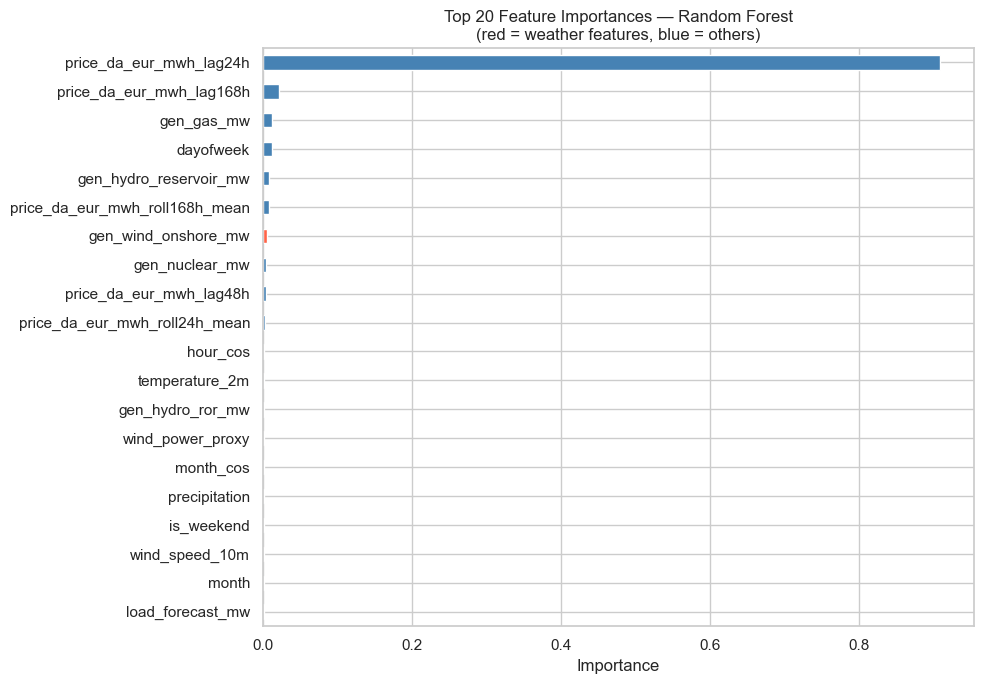


Top 10 features:
price_da_eur_mwh_lag24h           0.9096
price_da_eur_mwh_lag168h          0.0215
gen_gas_mw                        0.0123
dayofweek                         0.0117
gen_hydro_reservoir_mw            0.0084
price_da_eur_mwh_roll168h_mean    0.0079
gen_wind_onshore_mw               0.0054
gen_nuclear_mw                    0.0042
price_da_eur_mwh_lag48h           0.0031
price_da_eur_mwh_roll24h_mean     0.0020


In [9]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if 'weather' in c or 'temp' in c or 'wind' in c or 'hdd' in c or 'solar' in c
          else 'steelblue' for c in top20.index]
top20.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 Feature Importances — Random Forest\n(red = weather features, blue = others)')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_importance_rf.png', dpi=150)
plt.show()

print('\nTop 10 features:')
print(importances.nlargest(10).round(4).to_string())

## 9. Walk-Forward Backtest — Random Forest

In [10]:
# Stability check: MAE per month on test set (no retraining needed)
monthly_mae = []
for month, grp in y_test.groupby(y_test.index.to_period('M')):
    idx = grp.index
    mae_rf  = np.mean(np.abs(y_pred_rf.loc[idx]  - grp))
    mae_xgb = np.mean(np.abs(y_pred_xgb.loc[idx] - grp))
    monthly_mae.append({'month': str(month), 'RF': mae_rf, 'XGBoost': mae_xgb})

monthly_df = pd.DataFrame(monthly_mae).set_index('month')
print('MAE by month (test set):')
print(monthly_df.round(2).to_string())

MAE by month (test set):
            RF  XGBoost
month                  
2024-01  11.93    12.32
2024-02  11.04     9.91
2024-03  11.94    10.61
2024-04  16.66    14.70
2024-05  15.90    15.68
2024-06  17.71    18.07
2024-07  16.46    15.79
2024-08  19.48    19.59
2024-09  14.43    13.89
2024-10  19.01    17.26
2024-11  13.29    13.29
2024-12  19.92    22.48


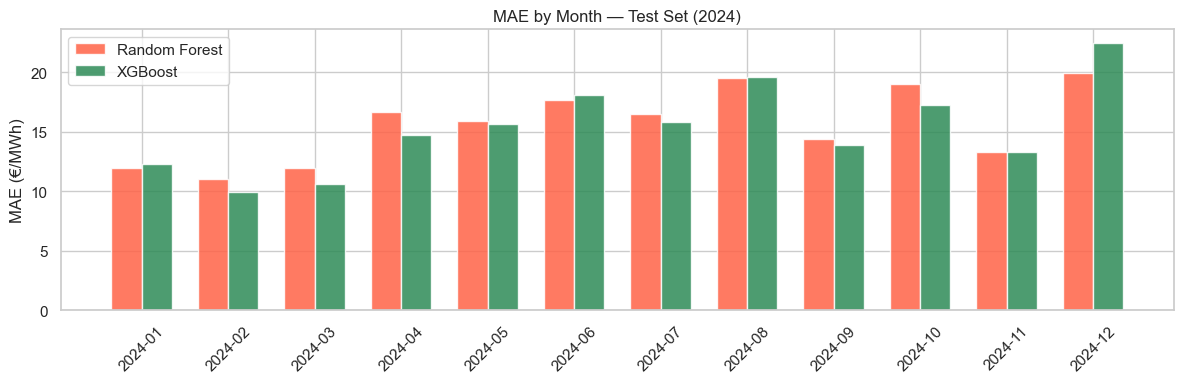

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(monthly_df))
w = 0.35
ax.bar([i - w/2 for i in x], monthly_df['RF'],     width=w, label='Random Forest', color='tomato',   alpha=0.85)
ax.bar([i + w/2 for i in x], monthly_df['XGBoost'], width=w, label='XGBoost',       color='seagreen', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_df.index, rotation=45)
ax.set_title('MAE by Month — Test Set (2024)')
ax.set_ylabel('MAE (€/MWh)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'backtest_mae_by_month.png', dpi=150)
plt.show()

## 10. Metrics Bar Chart — All Models

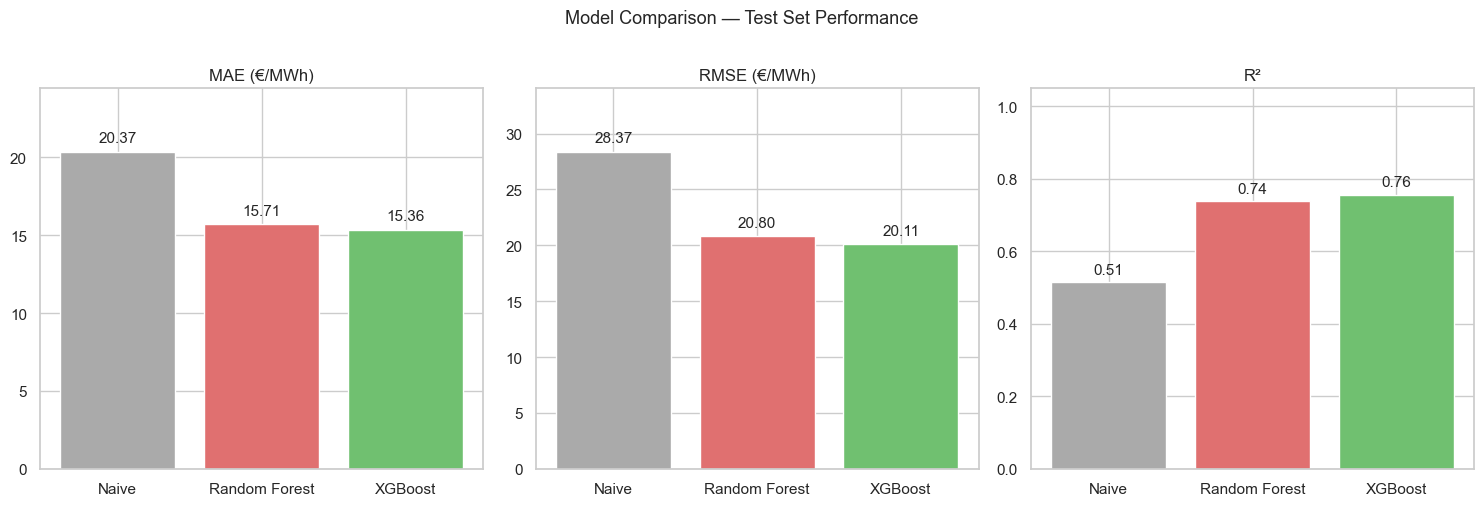

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Naive', 'Random Forest', 'XGBoost']
palette = ['#AAAAAA', '#E07070', '#70C070']

for ax, metric, label in [
    (axes[0], 'mae',  'MAE (€/MWh)'),
    (axes[1], 'rmse', 'RMSE (€/MWh)'),
    (axes[2], 'r2',   'R²'),
]:
    vals = [metrics_naive[metric], metrics_rf[metric], metrics_xgb[metric]]
    bars = ax.bar(models, vals, color=palette)
    ax.set_title(label)
    ax.set_ylim(0, max(vals) * 1.2 if metric != 'r2' else 1.05)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11)

fig.suptitle('Model Comparison — Test Set Performance', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()